In [82]:
using Pkg
using LARS
using Random
using Plots
using LinearAlgebra
using StatsBase

In [146]:
n,k = 10, 2

Random.seed!(123)
X = randn(n, k)
β = [2, 0.1]
y = X * β    + 0.1*randn(n)

path = lars(X, y; method = :lasso, standardize = true)

points = [  path.coefs[:, j] for j in 1:k+1  ]

path.coefs

2×3 Matrix{Float64}:
 0.0  1.94323  2.13159
 0.0  0.0      0.13543

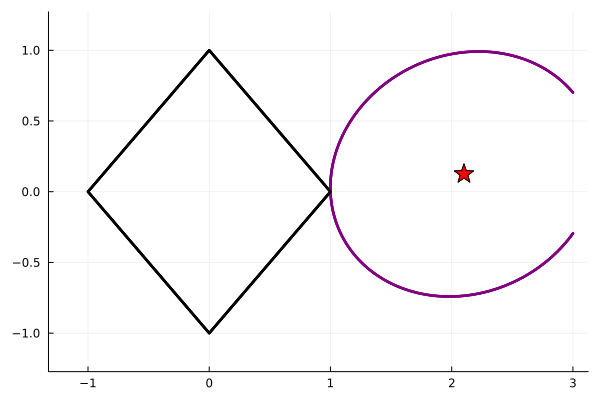

In [147]:
function g(x)
    return sum(  [abs(x[j]) for j in 1:length(x) ] )
end
   
function Q(b)
    return  (y - X*b)'*(y - X*b)
end 

OLS = inv(X'*X)*X'*y
   
   
x_grid = [  i for i in -1.2: 0.02 :3 ]
y_grid = [  i for i in -1.2: 0.02 :1.2 ]  
   
   
Zg = [g([xi, yi]) for yi in y_grid, xi in x_grid]
Zq = [Q([xi, yi]) for yi in y_grid, xi in x_grid]

L = [ Q([1,0]) ]
    
contour!(x_grid, y_grid, Zq, levels=L, linewidth=2.5,color =:purple,  colorbar = false)
contour!(x_grid, y_grid, Zg, levels=[1], linewidth=2.5,color = :black )
scatter!([OLS[1]], [OLS[2]], color=:red, markersize=10, label="" , marker =:star5)


In [148]:
c = X' *y 

A = argmax( [ abs(c[j])  for j in 1:k  ] )
s = vcat([sign(c[j]) for j in A]...)

S = Diagonal(s)   # seria Diagonal(S) se A tivesse mais de um elemento

Xk = hcat(   [X[:,j] for j in 1:A]  ... )
one = ones(length(A), 1) 

alpha = inv(  sqrt.(one'* inv( Xk' * Xk) * one )   )
w = alpha * inv( Xk' * Xk) * one
h = alpha * S * w                           # como A tem dimensão 1, fica trivialmente igual a 1


1×1 Matrix{Float64}:
 0.9999999999999999

Partindo de $\mu_0 = 0$, $A = [1]$, temos

$$
\beta_{1}(t) = t
$$

# Caso Multivariado

A partir de um nó $\mu_0$ e com $X$ e $y$ normalizados, defina

$$
c = X'( y - \mu_0) \qquad \mathcal{A} = \arg \max_j | c_j | \qquad 
s = \begin{bmatrix} \operatorname{sign} c_j & j \in \mathcal{A} \end{bmatrix}
\qquad S = \operatorname{diag}(s) 
\qquad \chi = \begin{bmatrix} s_j x_j & j \in \mathcal{A} \end{bmatrix}
$$

Então

$$
\alpha = \frac{1}{\sqrt{1_{\mathcal{A}}' (χ'χ)^{-1}1_{\mathcal{A}}  }}
\qquad h_{\mathcal{A}} = \alpha^2 S (χ'χ)^{-1}1_{\mathcal{A}}
$$

Tome o $h$ completo

$$
h_j = I \{ j \in \mathcal{A}\} h_{\mathcal{A}, a(j) }
$$

Em que $a(j)$ é o índice de $j$ dentro do vetor $\mathcal{A}$. Então

$$
\beta'(t)
=
\beta(t_0) + (t - t_0) h
$$

In [150]:
n,k = 100, 3

Random.seed!(123)
X = randn(n, k)     
X = mapslices(x -> (x .- mean(x)) ./ std(x), X; dims=1) # padroniza X
β = [3, 2 , 1] / 6      # norma 1

y = X * β    + 0.1*randn(n)
y = y_centered = y .- mean(y)     # padroniza y

path = lars(X, y; method = :lasso, standardize = true)

points = [  path.coefs[:, j] for j in 1:k+1  ]



4-element Vector{Vector{Float64}}:
 [0.0, 0.0, 0.0]
 [0.1521900615013233, 0.0, 0.0]
 [0.3019387853295024, 0.14974872382817914, 0.0]
 [0.5050198276483137, 0.3168603902668261, 0.1734905959012675]

In [160]:
μ = X * points[2]
c = X' *(y - μ) 

eps = 1e-6   # escolha sua tolerância
M = maximum(abs.(c))
A = findall(abs.(c) .>= M - eps)

s = vcat([sign(c[j]) for j in A]...)
S = Diagonal(s)  

Xk = hcat(   [X[:,j] for j in A]  ... )
one = ones(length(A), 1) 


alpha = 1 / sqrt(one'* inv( Xk' * Xk) * one )[1]  

w = alpha * inv( Xk' * Xk) * one
h = alpha* S * w


2×1 Matrix{Float64}:
 0.5000000000000002
 0.49999999999999983

In [166]:
μ = X * points[2]
c = X' *(y - μ) 

eps = 1e-6   # escolha sua tolerância
M = maximum(abs.(c))
A = findall(abs.(c) .>= M - eps)

s = vcat([sign(c[j]) for j in A]...)    
S = Diagonal(s)  

Xk = hcat(   [X[:,j] for j in A]  ... )
one = ones(length(A), 1) 


alpha = 1 / sqrt(one'* inv( Xk' * Xk) * one )[1]  

w = alpha * inv( Xk' * Xk) * one

h_A = alpha* S * w

function loc(j) 
    return findfirst(==(j), A)
end

h = [ j in A ?  h_A[loc(j)] : 0 for j in 1:k ]

3-element Vector{Real}:
 0.5000000000000002
 0.49999999999999983
 0

In [170]:
t0 = g(points[2])
t1 = g(points[3])

function beta(t)
    return  points[2] + (t - t0)*h
end    
    
    
print( beta(t0) ) 
print( beta(t1) ) 

[0.1521900615013233, 0.0, 0.0][0.30193878532950247, 0.14974872382817905, 0.0]